### Some hints for CW08 12.1 (A)(B)(C)

In [ ]:
# Generic Header
import sympy as sym
import numpy as np
import matplotlib.pyplot as plt
from sympy.plotting import plot
from sympy import oo,pi,I, factorial, sqrt, exp, S, assoc_laguerre, Float,Rational,simplify
from sympy.utilities.lambdify import lambdify,lambdastr

from IPython.display import display, Math, Latex
plt.style.use(['dark_background'])

#from sympy.functions.special.spherical_harmonics import Ynm
from scipy.constants import physical_constants
from scipy.optimize import minimize
sym.init_printing()

# just to be pretty 
from matplotlib import cm
from matplotlib import rc

rc('text', usetex=True)
rc('mathtext', fontset='cm')
rc('xtick', labelsize=16) 
rc('ytick', labelsize=16) 
rc('axes', labelsize=20) 
rc('axes.spines', **{'right':False, 'top':False})

from matplotlib.ticker import (MultipleLocator, FormatStrFormatter,
                               AutoMinorLocator)
%matplotlib inline

### define some symbols

In [2]:
r=sym.Symbol("r", real=True, positive=True)
rho=sym.Symbol("rho", real=True, positive=True)
# rhat=sym.Symbol("R", real=True, positive=True)
zeta=sym.Symbol("zeta", positive=True, nonzero=True)

### Some unit conversions

In [3]:
econv = physical_constants['Hartree energy in eV'][0]
econv   # eV per Hartree

27.211386245981

In [4]:
lconv = (1e10)*physical_constants['atomic unit of length'][0]
lconv   # Angstroms per a_0

0.529177210544

### Define Integrals symbolically

In [5]:
s = (1 + rho + (rho**2)/3)*sym.exp(-rho)
s

⎛ 2        ⎞    
⎜ρ         ⎟  -ρ
⎜── + ρ + 1⎟⋅ℯ  
⎝3         ⎠    

In [6]:
taa = Rational(1,2)
taa

1/2

In [7]:
vaaa = -1
vaaa

-1

In [8]:
tab = (1 + rho - (rho**2)/3)*sym.exp(-rho)/2
tab

⎛   2        ⎞    
⎜  ρ         ⎟  -ρ
⎜- ── + ρ + 1⎟⋅ℯ  
⎝  3         ⎠    
──────────────────
        2         

In [9]:
vaba =  simplify(-(1+rho)*sym.exp(-rho))
vaba

          -ρ
(-ρ - 1)⋅ℯ  

In [10]:
taa + vaaa   # The energy of an H atom

-1/2

In [11]:
simplify((tab + vaba)/s)    # This is also the energy of an H atom

-1/2

In [12]:
vaab = -(1-(1+rho)*sym.exp(-2*rho))/rho
vaab

         -2⋅ρ    
(ρ + 1)⋅ℯ     - 1
─────────────────
        ρ        

In [13]:
haa = taa + vaaa + vaab + 1/rho
simplify(haa)

⎛     2⋅ρ        ⎞      
⎜  ρ⋅ℯ           ⎟  -2⋅ρ
⎜- ────── + ρ + 1⎟⋅ℯ    
⎝    2           ⎠      
────────────────────────
           ρ            

In [14]:
hab = tab + vaba + vaba + s/rho
simplify(hab)

⎛   3      2          ⎞  -ρ
⎝- ρ  - 7⋅ρ  - 3⋅ρ + 6⎠⋅ℯ  
───────────────────────────
            6⋅ρ            

In [15]:
eg = ((haa + hab)/(1+s))   # The energy of the gerade (bonding state)
eg

                 ⎛   2        ⎞                               ⎛ 2        ⎞     ↪
                 ⎜  ρ         ⎟  -ρ                           ⎜ρ         ⎟  -ρ ↪
                 ⎜- ── + ρ + 1⎟⋅ℯ                  -2⋅ρ       ⎜── + ρ + 1⎟⋅ℯ   ↪
            -ρ   ⎝  3         ⎠       1   (ρ + 1)⋅ℯ     - 1   ⎝3         ⎠     ↪
2⋅(-ρ - 1)⋅ℯ   + ────────────────── - ─ + ───────────────── + ──────────────── ↪
                         2            2           ρ                  ρ         ↪
────────────────────────────────────────────────────────────────────────────── ↪
                               ⎛ 2        ⎞                                    ↪
                               ⎜ρ         ⎟  -ρ                                ↪
                               ⎜── + ρ + 1⎟⋅ℯ   + 1                            ↪
                               ⎝3         ⎠                                    ↪

↪     
↪     
↪     
↪    1
↪  + ─
↪    ρ
↪ ────
↪     
↪     
↪     
↪     

In [16]:
eu = ((haa-hab)/(1-s))
eu

                   ⎛   2        ⎞                               ⎛ 2        ⎞   ↪
                   ⎜  ρ         ⎟  -ρ                           ⎜ρ         ⎟   ↪
                   ⎜- ── + ρ + 1⎟⋅ℯ                  -2⋅ρ       ⎜── + ρ + 1⎟⋅ℯ ↪
              -ρ   ⎝  3         ⎠       1   (ρ + 1)⋅ℯ     - 1   ⎝3         ⎠   ↪
- 2⋅(-ρ - 1)⋅ℯ   - ────────────────── - ─ + ───────────────── - ────────────── ↪
                           2            2           ρ                  ρ       ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                 ⎛ 2        ⎞                                  ↪
                                 ⎜ρ         ⎟  -ρ                              ↪
                               - ⎜── + ρ + 1⎟⋅ℯ   + 1                          ↪
                                 ⎝3         ⎠                                  ↪

↪       
↪ -ρ    
↪       
↪      1
↪ ── + ─
↪      ρ
↪ ──────
↪       
↪       
↪       
↪       

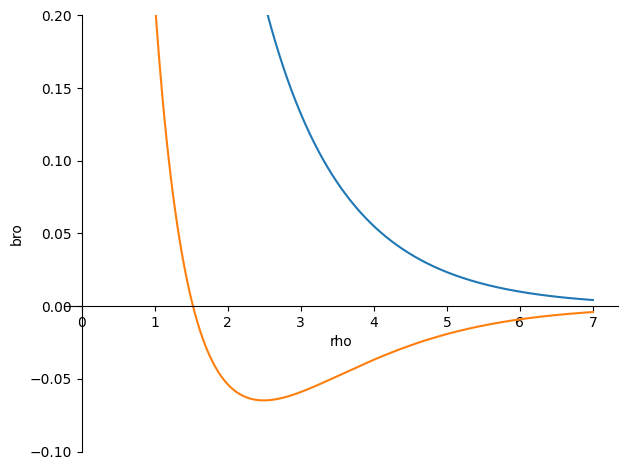

In [17]:
# Plot shifing the energies up by the energy of an H atom
# Still in atomic units
plt.rcParams.update(plt.rcParamsDefault)

plot(eu+.5,eg+.5,(rho,0.1,7), axis_center=(0,0), ylim = (-.1,0.2),xlabel="rho",ylabel="bro")
plt.show()


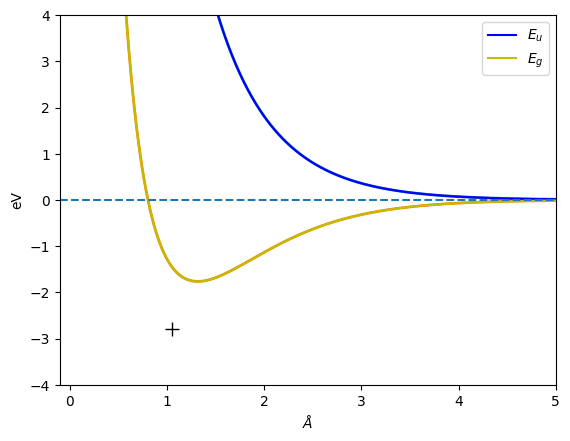

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -1.7641420657985574
        x: [ 1.319e+00]
      nit: 5
      jac: [ 2.861e-06]
 hess_inv: [[ 1.632e-01]]
     nfev: 14
     njev: 7


In [18]:
#my hw to plit eV vs angstroms
eu2 = lambdify(r,(eu.subs(rho, r*1.88973)+0.5) * 27.2114)  # Convert to eV and adjust for the energy of an H atom
eg2 = lambdify(r,(eg.subs(rho, r*1.88973)+0.5) * 27.2114)  # Convert to eV and adjust for the energy of an H atom

plt.figure(2)
t = np.arange(0.1,10.0,0.01)
a = eu2(t)
line, = plt.plot(t,a,lw=2)

b = eg2(t)
line, = plt.plot(t,b,lw=2)

plt.ylim(-4,4)
plt.xlim(-0.1,5.0)

plt.plot(t, a, "-b", label=r'$E_{u}$')
plt.plot(t, b, "-y", label=r'$E_{g}$')
plt.legend(loc="upper right")

#plt.figtext(0.5,-0.1,"Scaled potential vs. scaled displacement", ha='center', fontsize=12)
plt.xlabel(r'$\AA$')
plt.ylabel("eV")

plt.axhline(0.0, linestyle='--')
plt.plot([1.052],[-2.788], marker='+', markersize=10, color='black')  # Add a red dot at the minimum energy point
plt.show()

print(minimize(eg2,1))

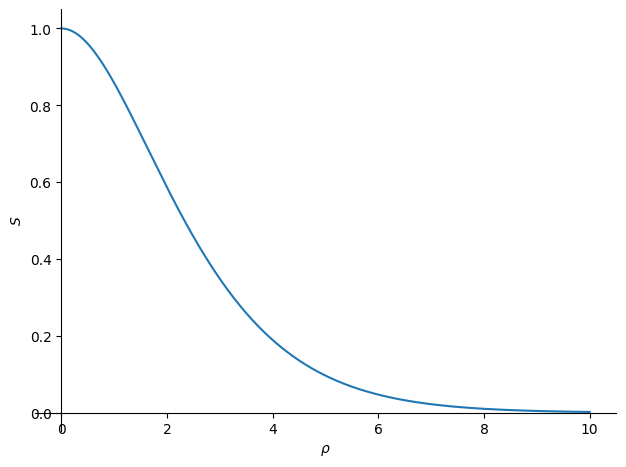

In [19]:
# Plot the overlap
plot(s,(rho,0.001,10),axis_center=(0,0),xlabel=r"$\rho$",ylabel=r"$S$")
plt.show()

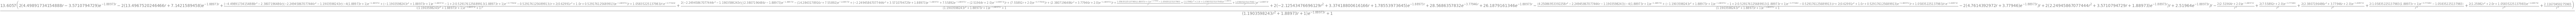

In [20]:
# The second derivative (for harmonic frequency)
eg3 = (eg.subs(rho, r*1.88973)+0.5) * 27.2114
ddeg = sym.diff(eg3,r,2)
ddeg

### Fancier plots

In [21]:
feg = lambdify([rho],eg+.5,modules=['numpy'])
feu = lambdify([rho],eu+.5,modules=['numpy'])  # for later plot of E(R)
fddeg = lambdify([r],ddeg,modules=['numpy']) # for later vib freq calc
fddeg(1.319)

In [22]:
# find the equilibrium point
smin = minimize(feg,[2.5])
sx = smin.x[0]
sy = smin.fun
sx  # The equilibrium bond length in a0

In [23]:
print("bond length",sx*lconv,"  Angstroms")

bond length 1.3191288195583681   Angstroms


In [24]:
print("bond dis energy",(-sy)*econv,"  eV")

bond dis energy 1.764141172863699   eV


In [25]:
keq = fddeg(sx)
keq   # force constant in atomic units

In [26]:
physical_constants["proton-electron mass ratio"][0]

In [27]:
# calculate the vibational frequency in wavenumbers
# the HARD way
sec = physical_constants["atomic unit of time"][0]
cee = 100*physical_constants["speed of light in vacuum"][0]
mu = physical_constants["proton-electron mass ratio"][0]/2.0   # reduced mass of 1^H_2 in au
freq = (1.0/(2.0*np.pi))*np.sqrt(keq/mu)  # harmonic frequency in au
print("frequency in atomic units = %10.5e"%freq)
nu = freq/sec
print("frequency in Hz = %10.5e"%nu)
wnum = nu/cee
print("vibrational frequency = %8.2f wavenumbers"%wnum)

frequency in atomic units =        nan
frequency in Hz =        nan
vibrational frequency =      nan wavenumbers


C:\Users\petrov\AppData\Local\Temp\ipykernel_43556\3904894907.py:6: RuntimeWarning: invalid value encountered in sqrt
  freq = (1.0/(2.0*np.pi))*np.sqrt(keq/mu)  # harmonic frequency in au


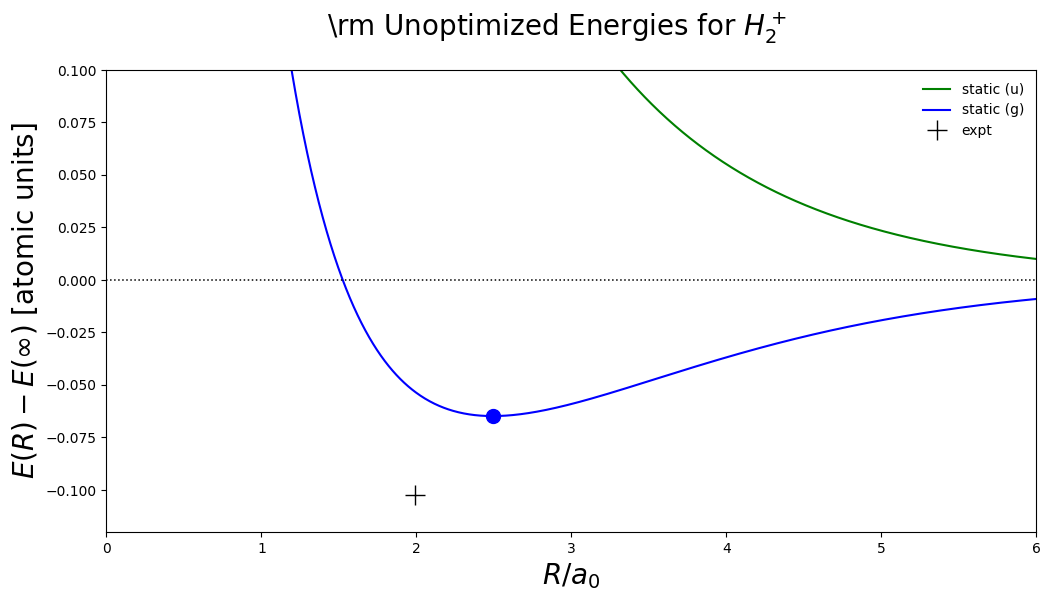

In [28]:
# make a plot in atomic units
xlow=0
xhigh=6
ylow = -0.12
yhigh = 0.1
x2 = np.linspace(1.0,xhigh,1000)
y2 = []
y4 = []
for x in x2:
    y2 += [feg(x)]
    y4 += [feu(x)]
plt.figure(figsize=(12,6))
plt.plot(x2,y4,color="green",label='static (u)')
plt.plot(x2,y2,color="blue",label='static (g)')
plt.xlim(0,xhigh)
plt.ylim(ylow,yhigh)
plt.hlines(0,0,xhigh,linestyle="dotted",linewidth=1.1,color="black")
plt.plot(1.052/lconv,-2.788/econv,'+',markersize=15,linewidth=4,color="black",label='expt')
plt.plot(sx,sy,'o',markersize=10,linewidth=2,color="blue")
plt.legend(frameon=False)
plt.xlabel(r'$R/a_0$',fontsize=20)
plt.ylabel(r'$E(R) - E(\infty)$ [atomic units]',fontsize=20)
plt.suptitle(r'\rm Unoptimized Energies for $H_2^+$',fontsize=20)
plt.show()

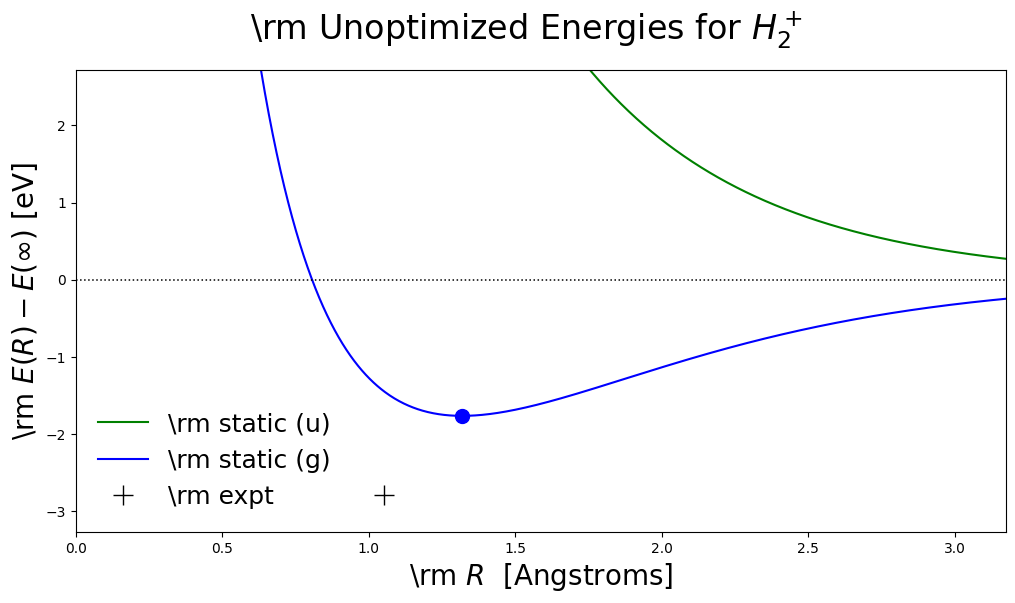

In [29]:
# make a plot in requested units
#escale = econv
#rscale = lconv
xlow=0*lconv
xhigh=6*lconv
ylow = -0.12*econv
yhigh = 0.1*econv
x2 = np.linspace(1.0*lconv,xhigh,1000)
y2 = []
y4 = []
for x in x2:
    y2 += [econv*feg(x/lconv)]
    y4 += [econv*feu(x/lconv)]
plt.figure(figsize=(12,6))
plt.plot(x2,y4,color="green",label=r'\rm static (u)')
plt.plot(x2,y2,color="blue",label=r'\rm static (g)')
plt.xlim(0,xhigh)
plt.ylim(ylow,yhigh)
plt.hlines(0,0*econv,xhigh,linestyle="dotted",linewidth=1.1,color="black")
plt.plot((1.052),(-2.788),'+',markersize=15,\
         linewidth=4,color="black",label=r'\rm expt')
plt.plot(lconv*sx,econv*sy,'o',markersize=10,linewidth=2,color="blue")
plt.legend(frameon=False,fontsize=18)
plt.xlabel(r'\rm $R$  [Angstroms]',fontsize=20)
plt.ylabel(r'\rm $E(R) - E(\infty)$ [eV]',fontsize=20)
plt.suptitle(r'\rm Unoptimized Energies for $H_2^+$',fontsize=24)
plt.show()

In [ ]:
z = sym.Symbol("zeta", real=True, positive=True)
R = sym.Symbol("Rhat", real=True, positive=True)
